# Spline Policy

In [1]:
import os, sys, pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Jupyter sets cwd to the notebook's own directory; the rest of the repo's
# scripts (run/*.py) all assume cwd == spline_policy/, so match that convention.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, ".")
sys.path.insert(0, "policy")
sys.path.insert(0, "run/demonstration")

from policy.diffusion_policy.planning.quadratic_spline import QuadraticSpline
from policy.spline_policy_mixin import SplinePolicyMixin
from tool.visualization.trajectory import integrate_trajectories, plot_trajectory_with_arrows, glow_line, gradient_colors

torch.manual_seed(7)
np.random.seed(7)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs("outputs", exist_ok=True)


class MinimalSplinePolicy(SplinePolicyMixin):
    """Thin SplinePolicyMixin host for cells that don't need a full
    trained backbone. Every trajectory-decode and flow-field computation in
    this notebook goes through this mixin's own methods
    (`_decode_prediction`, `generate_dynamical_system`,
    `propagate_flow_uncertainty`) -- exactly what the real policy classes
    (`DiffusionUnetLowdimPolicy` & co.) do
    internally -- rather than calling `QuadraticSpline`/
    `dynamical_system_single_step` directly."""

    def __init__(self, poly, action_dim, lambda_dist=0.5, step_size=3.0):
        self.device = torch.device(DEVICE)
        self.action_dim = action_dim
        self._init_spline(poly, lambda_dist=lambda_dist, step_size=step_size)


print("cwd:", os.getcwd())

## 1. Trajectory decoding & structured representation

The left panel is a fixed-resolution action trajectory: discrete
points with no structure between them. Fitting the same points into a
compact set of spline parameters
gives the right panel: a small, connected set of control points that decode
into a continuous curve. The `encode_trajectory` call works unchanged on an action trajectory; just swap `waypoints` for its output.

In [2]:
from policy.diffusion_policy.common.replay_buffer import ReplayBuffer

s_demo = ReplayBuffer.copy_from_path("data/demonstrations/S.zarr", keys=["action"]).get_episode(0)["action"]
waypoints = torch.tensor(s_demo, dtype=torch.float32, device=DEVICE).unsqueeze(0)  # (1, 20, 2): a VLA-style action trajectory

poly = QuadraticSpline(nbFct=3, nbSeg=8, nbDim=2, nPoints=200, device=DEVICE)
sp = MinimalSplinePolicy(poly, action_dim=2)
w = sp.encode_trajectory(waypoints)  # fit control points -> spline params w

traj_fine = sp._decode_prediction(w.clone(), is_continue=False)
traj_np = traj_fine[0].detach().cpu().numpy()
waypoints_np = waypoints[0].detach().cpu().numpy()
ctrl_np = sp.decode_control_points()[0].detach().cpu().numpy()

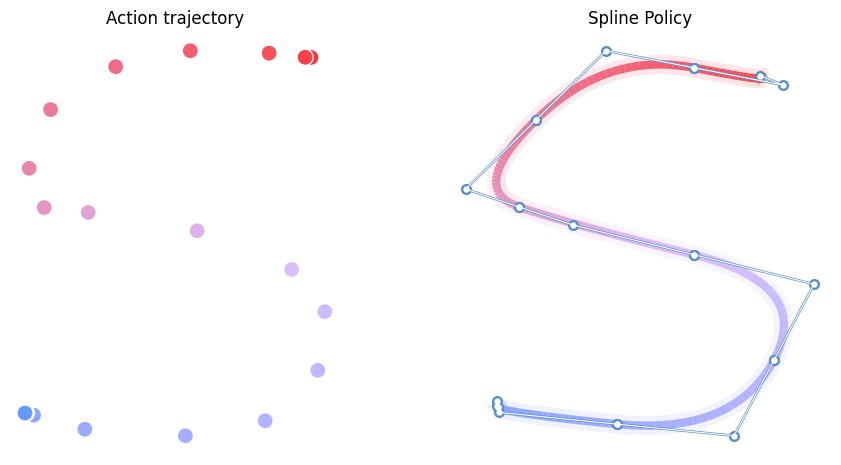

In [3]:
pt_colors = gradient_colors(len(waypoints_np))

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

ax = axes[0]
ax.scatter(waypoints_np[:, 0], waypoints_np[:, 1], c=pt_colors, s=135, zorder=3, edgecolor="white", linewidth=1.0)
ax.set_title("Action trajectory")
ax.set_aspect("equal"); ax.autoscale(); ax.axis("off")

ax = axes[1]
glow_line(ax, traj_np, lw=6)
ax.plot(ctrl_np[:, 0], ctrl_np[:, 1], "o-", c="#5b8fc9", markersize=7, linewidth=1.8, zorder=3)
ax.plot(ctrl_np[:, 0], ctrl_np[:, 1], "o-", c="white", markersize=3.5, linewidth=0.8, zorder=3.1)
ax.set_title("Spline Policy")
ax.set_aspect("equal"); ax.autoscale(); ax.axis("off")

plt.show()

## 2. Continuity across replanning

When a policy replans mid-execution, the new segment can ignore the previous
one, match its end position only, or match both position and direction.

In [4]:
two_fifths = int(len(s_demo) * 1 / 2)
seg_a = torch.tensor(s_demo[:two_fifths], dtype=torch.float32, device=DEVICE).unsqueeze(0)
seg_b = torch.tensor(s_demo[-two_fifths:], dtype=torch.float32, device=DEVICE).unsqueeze(0)

def fit(waypoints):
    sp = MinimalSplinePolicy(QuadraticSpline(nbFct=3, nbSeg=3, nbDim=2, device=DEVICE), action_dim=2)
    return sp, sp.encode_trajectory(waypoints)


def ctrl_points(sp):
    return sp.decode_control_points()[0].detach().cpu().numpy()


sp_a, w_a = fit(seg_a)
traj_a = sp_a._decode_prediction(w_a.clone(), is_continue=True)  # caches sp_a.poly.params
traj_a_np = traj_a[0].detach().cpu().numpy()
ctrl_a_np = ctrl_points(sp_a)  # captured before sp_a.poly.params is overwritten by the C1 replan below
boundary_pt = traj_a[0, -1:].clone()

_, w_b = fit(seg_b)

# no continuity: independent fit, no boundary matching
sp_none, _ = fit(seg_b)
traj_none = sp_none._decode_prediction(w_b.clone(), is_continue=False)

# C0 only: fresh poly (no cached params), explicit last_state -> position-only match
sp_c0, _ = fit(seg_b)
traj_c0 = sp_c0._decode_prediction(w_b.clone(), is_continue=True, last_state=boundary_pt)

# C1: replan through the SAME poly instance that produced traj_a -> its cached
# .params triggers the position+tangent boundary match
traj_c1 = sp_a._decode_prediction(w_b.clone(), is_continue=True)

variants = [
    ("No continuity", traj_none[0].detach().cpu().numpy(), ctrl_points(sp_none)),
    ("C0 continuity", traj_c0[0].detach().cpu().numpy(), ctrl_points(sp_c0)),
    ("C1 continuity", traj_c1[0].detach().cpu().numpy(), ctrl_points(sp_a)),
]

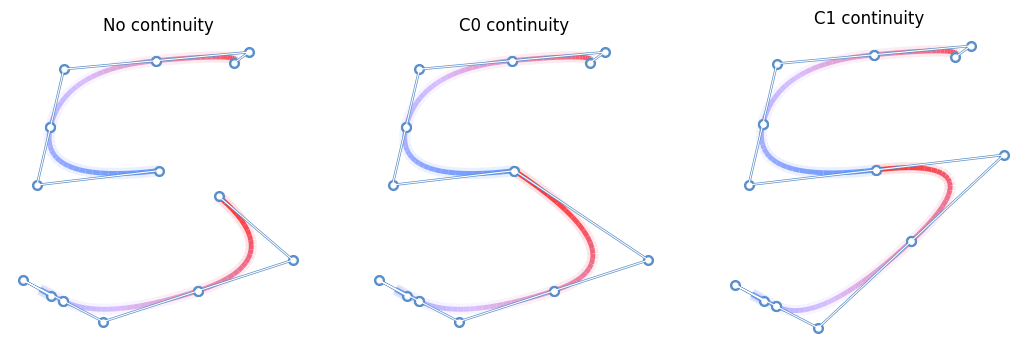

In [5]:
def plot_ctrl(ax, ctrl_np):
    ax.plot(ctrl_np[:, 0], ctrl_np[:, 1], "o-", c="#5b8fc9", markersize=7, linewidth=1.8, zorder=3)
    ax.plot(ctrl_np[:, 0], ctrl_np[:, 1], "o-", c="white", markersize=3.5, linewidth=0.8, zorder=3.1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (title, traj_b_np, ctrl_b_np) in zip(axes, variants):
    glow_line(ax, traj_a_np, lw=3.5)
    glow_line(ax, traj_b_np, lw=3.5)
    plot_ctrl(ax, ctrl_a_np)
    plot_ctrl(ax, ctrl_b_np)
    ax.set_title(title)
    ax.set_aspect("equal"); ax.autoscale(); ax.axis("off")
plt.show()

## 3. Flow field and perturbation recovery

`generate_dynamical_system` turns the curve into a velocity field: nearby
states are pulled toward it and carried along its direction. A trajectory
representation alone does not define off-trajectory behavior; the induced
flow field provides this feedback (`integrate_trajectories`, RK4). Same "S"
spline as before.

In [6]:
sp_f = sp  # reuse the earlier fitted spline directly
traj_f_np = traj_np

margin = 0.25 * max(waypoints_np[:, 0].ptp(), waypoints_np[:, 1].ptp())
x_min, x_max = waypoints_np[:, 0].min() - margin, waypoints_np[:, 0].max() + margin
y_min, y_max = waypoints_np[:, 1].min() - margin, waypoints_np[:, 1].max() + margin

N = 25
xs = torch.linspace(x_min, x_max, N, device=DEVICE)
ys = torch.linspace(y_min, y_max, N, device=DEVICE)
x_grid, y_grid = torch.meshgrid(xs, ys, indexing="xy")
query = torch.stack([x_grid.flatten(), y_grid.flatten()], dim=1)
p = query.unsqueeze(0).expand(sp_f.poly.nbSeg, N * N, 2).contiguous()
field_result = sp_f.generate_dynamical_system({"action": p})
vec = field_result["gradient_field"].squeeze(0)

x_grid_np = x_grid.detach().cpu().numpy()
y_grid_np = y_grid.detach().cpu().numpy()
vec_np = vec.detach().cpu().numpy()
field = np.concatenate([query.detach().cpu().numpy(), vec_np], axis=1)  # (N*N, 4): x, y, u, v

# perturb random points off to the side of the curve, then just integrate
rng = np.random.default_rng(0)
n_perturb = 3
perturbed_starts, recovered = [], []
for _ in range(n_perturb):
    i = rng.integers(int(0.1 * len(traj_f_np)), int(0.9 * len(traj_f_np)))
    sign = rng.choice([-1, 1])
    offset = rng.uniform(0.3, 0.7) * margin
    tangent = traj_f_np[i + 2] - traj_f_np[i - 2]
    normal = np.array([-tangent[1], tangent[0]]) / np.linalg.norm(tangent)
    start = traj_f_np[i] + normal * offset * sign

    path = integrate_trajectories(field, start[None, :], dt=0.1, n_steps=10000)[0]
    perturbed_starts.append(start)
    recovered.append(path)
perturbed_starts = np.array(perturbed_starts)

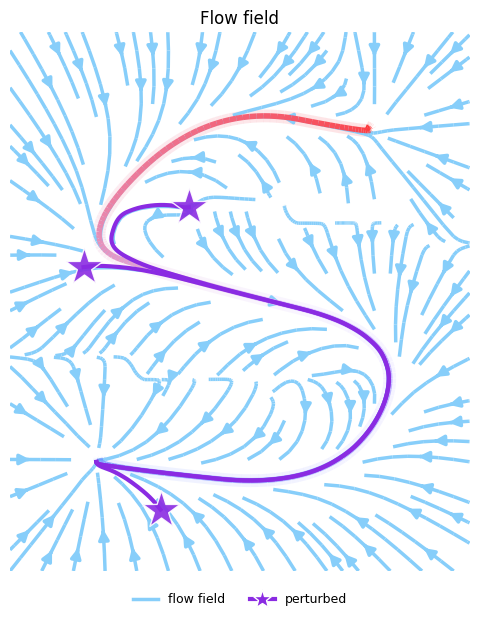

In [7]:
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(7, 7))
ax.streamplot(
    x_grid_np, y_grid_np,
    vec_np[:, 0].reshape(N, N), vec_np[:, 1].reshape(N, N),
    color="lightskyblue", linewidth=2.5, density=1.0, arrowsize=1.5,
)
glow_line(ax, traj_f_np, lw=4)
for s, r in zip(perturbed_starts, recovered):
    ax.plot(r[:, 0], r[:, 1], color="blueviolet", linewidth=3, zorder=40)
    ax.scatter(s[0], s[1], marker="*", s=800, color="blueviolet", edgecolors="white", linewidths=1, zorder=41, alpha=0.9)
ax.set_title("Flow field")
ax.set_aspect("equal"); ax.axis("off")

legend_handles = [
    mlines.Line2D([], [], color="lightskyblue", lw=2.5, label="flow field"),
    mlines.Line2D([], [], color="blueviolet", lw=3, marker="*", markersize=14, markeredgecolor="white", label="perturbed"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=9, frameon=False)
plt.show()

## 4. Uncertainty propagation

Works the same way with a real policy model: maintain a distribution over the
input, run inference, and get a distribution over `w`. Here we just sample
`w` directly for convenience. `propagate_flow_uncertainty` takes that batch
and returns mean/variance for the control points, the trajectory, and the
flow field it induces -- plotted directly below from just those two moments.

In [8]:
rng_u = np.random.default_rng(1)
M = 40
w_noise_std = 0.05 * margin
w_np = w.detach().cpu().numpy()
w_samples = torch.tensor(
    w_np + rng_u.normal(scale=w_noise_std, size=(M,) + w_np.shape[1:]),
    dtype=torch.float32, device=DEVICE,
)

# propagate on a dedicated spline instance, so this doesn't clobber
# sp.poly.params (later cells rely on it staying at the nominal fit)
sp_u = MinimalSplinePolicy(QuadraticSpline(nbFct=3, nbSeg=poly.nbSeg, nbDim=2, nPoints=poly.nPoints, device=DEVICE), action_dim=2)

x_grid4, y_grid4 = torch.meshgrid(
    torch.linspace(x_min, x_max, 60, device=DEVICE), torch.linspace(y_min, y_max, 60, device=DEVICE), indexing="ij"
)
query4 = torch.stack([x_grid4.flatten(), y_grid4.flatten()], dim=1)
ctrl_mean, ctrl_var, traj_mean, traj_var, field_mean, field_var = sp_u.propagate_flow_uncertainty(query4, w_samples)

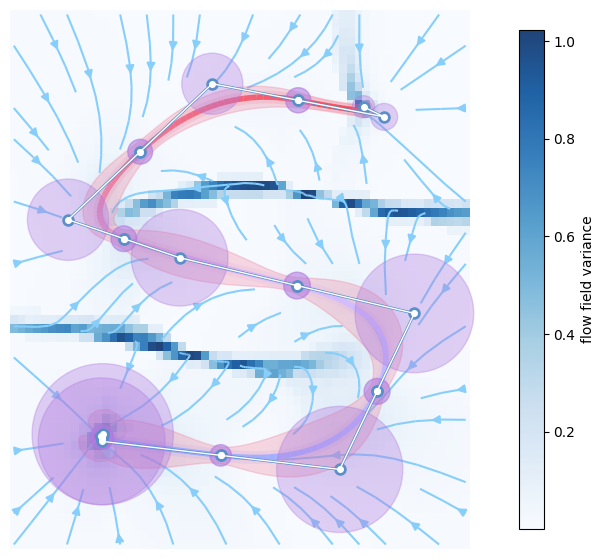

In [9]:
ctrl_mean_np = ctrl_mean.detach().cpu().numpy()
ctrl_var_np = ctrl_var.detach().cpu().numpy()
traj_mean_np = traj_mean.detach().cpu().numpy()
traj_var_np = traj_var.detach().cpu().numpy()
field_mean_np = field_mean.detach().cpu().numpy()
field_var_np = field_var.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(7, 7))
variance_map = field_var_np.sum(-1).reshape(60, 60)
mesh = ax.pcolormesh(x_grid4.detach().cpu().numpy(), y_grid4.detach().cpu().numpy(), variance_map, shading="auto", cmap="Blues", alpha=0.9, zorder=-1)
ax.streamplot(
    x_grid4.detach().cpu().numpy().T, y_grid4.detach().cpu().numpy().T,
    field_mean_np[:, 0].reshape(60, 60).T, field_mean_np[:, 1].reshape(60, 60).T,
    color="lightskyblue", linewidth=1.5, density=0.6, arrowsize=1.2, zorder=0,
)

# trajectory band: mean +/- 2 std along the local normal direction
tangent = np.zeros_like(traj_mean_np)
tangent[1:-1] = traj_mean_np[2:] - traj_mean_np[:-2]
tangent[0] = traj_mean_np[1] - traj_mean_np[0]
tangent[-1] = traj_mean_np[-1] - traj_mean_np[-2]
tangent /= np.clip(np.linalg.norm(tangent, axis=-1, keepdims=True), 1e-8, None)
normal = np.stack([-tangent[:, 1], tangent[:, 0]], axis=-1)
band_half = 2 * np.sqrt((traj_var_np * normal**2).sum(-1))
band = np.vstack([traj_mean_np + band_half[:, None] * normal, (traj_mean_np - band_half[:, None] * normal)[::-1]])
ax.fill(band[:, 0], band[:, 1], color="#ef6a8a", alpha=0.25, zorder=2)
glow_line(ax, traj_mean_np, lw=4)

# control points: circle radius from variance directly (mean/var only, no covariance ellipse)
for c, r in zip(ctrl_mean_np, np.sqrt(ctrl_var_np.sum(-1))):
    ax.add_patch(plt.Circle(c, 2 * r, color="#b07adf", alpha=0.35, zorder=4))
ax.plot(ctrl_mean_np[:, 0], ctrl_mean_np[:, 1], "o-", c="#5b8fc9", markersize=8, linewidth=2, zorder=5)
ax.plot(ctrl_mean_np[:, 0], ctrl_mean_np[:, 1], "o-", c="white", markersize=4, linewidth=1, zorder=5.2)

cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("flow field variance")
ax.set_aspect("equal"); ax.axis("off")
plt.show()

## 5. Null-space control integration

A flow vector from the task-space field is mapped to a configuration-space
velocity through the robot's Jacobian (`map_taskspace_to_jointspace`), then
combined with a higher-priority collision-avoidance direction through
null-space projection (`null_space_project`): the flow is followed wherever
it doesn't conflict with avoidance.

In [10]:
from robot.panda_layer import PandaLayer

robot = PandaLayer(device=DEVICE)
theta = robot.theta_mid.unsqueeze(0).to(dtype=robot.dtype)
base = torch.eye(4, dtype=robot.dtype, device=DEVICE).unsqueeze(0)
eef_cur, eef_pertubed, _ = robot.get_pertubed_eef(base, theta, delta=1e-3)

# task-space flow vector, queried from the mixin-derived flow field
# at the robot's current end-effector position
query_pt = eef_cur.position[:, :2].to(dtype=torch.float32)
query_pt = query_pt.unsqueeze(0).expand(sp_f.poly.nbSeg, 1, 2).contiguous()
flow_vec = sp_f.generate_dynamical_system({"action": query_pt})["gradient_field"][:, 0, :].to(robot.dtype)
q_dot_flow = robot.map_taskspace_to_jointspace(flow_vec, eef_cur, eef_pertubed, delta=1e-3)
q_dot_flow_np = q_dot_flow[0].detach().cpu().numpy()

# illustrative avoidance direction, set to partially oppose q_dot_flow's own
# dominant joints so the null-space projection has something to resolve
j1, j2 = np.argsort(np.abs(q_dot_flow_np))[-2:]
collision_vec = torch.zeros(1, robot.dof, dtype=robot.dtype, device=DEVICE)
collision_vec[0, j1] = -0.6 * q_dot_flow[0, j1]
collision_vec[0, j2] = 0.5 * q_dot_flow[0, j2]

q_dot_action = sp_f.null_space_project(main_task=collision_vec, auxiliary_task=q_dot_flow)
q_dot_flow_proj = q_dot_action - collision_vec  # auxiliary alone, after projection but before adding main_task back

flow_vec_np = flow_vec[0].detach().cpu().numpy()
collision_vec_np = collision_vec[0].detach().cpu().numpy()
q_dot_flow_proj_np = q_dot_flow_proj[0].detach().cpu().numpy()
q_dot_action_np = q_dot_action[0].detach().cpu().numpy()

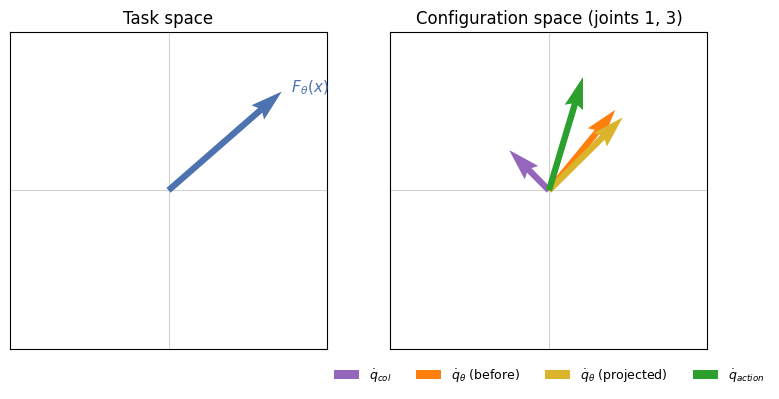

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

ax = axes[0]
ax.quiver(0, 0, flow_vec_np[0], flow_vec_np[1], color="#4c72b0", angles="xy", scale_units="xy", scale=1, width=0.02)
lim = max(abs(flow_vec_np).max(), 1e-6) * 1.4
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_title("Task space"); ax.set_aspect("equal")
ax.text(flow_vec_np[0], flow_vec_np[1], r"  $F_\theta(x)$", color="#4c72b0", fontsize=11)
ax.axhline(0, color="lightgray", lw=0.8, zorder=0); ax.axvline(0, color="lightgray", lw=0.8, zorder=0)
ax.set_xticks([]); ax.set_yticks([])

ax = axes[1]
vecs = [
    (collision_vec_np, "#9467bd", r"$\dot q_{col}$"),
    (q_dot_flow_np, "#ff7f0e", r"$\dot q_\theta$ (before)"),
    (q_dot_flow_proj_np, "#dbb42c", r"$\dot q_\theta$ (projected)"),
    (q_dot_action_np, "#2ca02c", r"$\dot q_{action}$"),
]
lim2 = max(max(abs(v[j1]), abs(v[j2])) for v, _, _ in vecs) * 1.4
for v, color, label in vecs:
    ax.quiver(0, 0, v[j1], v[j2], color=color, angles="xy", scale_units="xy", scale=1, width=0.02, label=label)
ax.set_xlim(-lim2, lim2); ax.set_ylim(-lim2, lim2)
ax.set_title(f"Configuration space (joints {j1}, {j2})"); ax.set_aspect("equal")
ax.axhline(0, color="lightgray", lw=0.8, zorder=0); ax.axvline(0, color="lightgray", lw=0.8, zorder=0)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=9, frameon=False)

plt.show()

## 6. Training

Download and extract the Push-T demonstrations from the upstream Diffusion Policy release.

In [12]:
%%bash
PUSHT_DATASET=data/pusht/pusht_cchi_v7_replay.zarr
if [ ! -d "$PUSHT_DATASET" ]; then
    mkdir -p data
    wget -O data/pusht.zip https://diffusion-policy.cs.columbia.edu/data/training/pusht.zip
    unzip data/pusht.zip -d data
    rm data/pusht.zip
fi

This creates `data/pusht/pusht_cchi_v7_replay.zarr`, shared by the low-dimensional and image-based Push-T configurations. Train the low-dimensional spline policy used below:

In [ ]:
%%bash
python run/common/train.py --config-name=train_diffusion_unet_lowdim_spline_workspace \
    training.seed=42 training.device=cuda:0 \
    hydra.run.dir='data/outputs/pusht_spline'

The checkpoint is saved to `data/outputs/pusht_spline/checkpoints/latest.ckpt`. Choose another `config/train/train_*_spline_workspace.yaml` to train a different backbone or observation modality.

### Using a different backbone

| Integration | Retraining | Backbone output | Use case |
|---|---:|---|---|
| End-to-end prediction | Yes | Spline parameters `w` with shape `(B, nbSeg+2, Da)` | Training or fine-tuning a policy |
| Post-hoc fitting | No | Raw action waypoints | Adding spline structure to an existing policy, such as a VLA |

## 7. Push-T deployment: planning and high-rate flow control

The policy predicts a spline trajectory, and the high-rate controller queries its flow
field at the measured agent position. To demonstrate recovery, the rollout perturbs
the agent immediately after every third prediction.

In [12]:
import collections
import dill
import hydra
import imageio.v2 as imageio
from IPython.display import Video

from policy.diffusion_policy.env.pusht.pusht_env import PushTEnv

CHECKPOINT = pathlib.Path("data/outputs/pusht_spline/checkpoints/latest.ckpt")

payload = torch.load(CHECKPOINT, map_location=DEVICE, pickle_module=dill)
policy = hydra.utils.instantiate(payload["cfg"].policy)
state_dict = payload["ema_model_state"] if payload["ema_model_state"] is not None else payload["model_state"]
policy.load_state_dict(state_dict)
policy.to(DEVICE).eval();

In [13]:
ROLLOUT_SEED = 42
POLICY_TIMESTEP_HZ = 10  # sampling rate of the training trajectories
FLOW_HZ = 100            # flow-feedback frequency
FLOW_TARGET_SPEED = 2000.0  # target-position rate [pixels/s]
FLOW_ATTRACTION = 1.0   # attraction toward the predicted spline
DISTURBANCE_EVERY_TRAJS = 3
DISTURBANCE_DISTANCE = 100.0  # pixels
VIDEO_HZ = POLICY_TIMESTEP_HZ
VIDEO_STOP_REWARD = 0.90  # visualization cutoff; gradient integration introduces small terminal error
ROLLOUT_SECONDS = 60

torch.manual_seed(ROLLOUT_SEED)
np.random.seed(ROLLOUT_SEED)
policy.lambda_dist = FLOW_ATTRACTION
env = PushTEnv(legacy=True, render_action=True, sim_hz=100)
env.control_hz = FLOW_HZ
env.seed(ROLLOUT_SEED)
obs = env.reset()

OBS_STRIDE = FLOW_HZ // POLICY_TIMESTEP_HZ  # flow steps between policy-rate observations
TRAJ_EXECUTION_STEPS = policy.n_action_steps  # policy timesteps executed from each trajectory
CUTOFF_HORIZON = TRAJ_EXECUTION_STEPS / policy.horizon  # normalized handoff point on the predicted trajectory
TRAJ_EXECUTION_SECONDS = TRAJ_EXECUTION_STEPS / POLICY_TIMESTEP_HZ  # simulated execution duration per trajectory
TRAJ_EXECUTION_FLOW_STEPS = round(TRAJ_EXECUTION_SECONDS * FLOW_HZ)  # flow steps per trajectory execution
RENDER_INTERVAL_FLOW_STEPS = FLOW_HZ // VIDEO_HZ  # flow steps between rendered video frames
FLOW_TARGET_DISPLACEMENT_PER_STEP = FLOW_TARGET_SPEED / FLOW_HZ  # target increment per flow step [pixels]
MAX_STEPS = round(ROLLOUT_SECONDS * FLOW_HZ)  # total number of flow-control steps
history_length = (policy.n_obs_steps - 1) * OBS_STRIDE + 1
obs_history = collections.deque([obs.copy()] * history_length, maxlen=history_length)
frames, executed, plans, disturbance_positions, rewards = [], [], [], [], []
print(f"physics {env.sim_hz} Hz | flow {FLOW_HZ} Hz | policy input {POLICY_TIMESTEP_HZ} Hz")

for step in range(MAX_STEPS):
    if step % TRAJ_EXECUTION_FLOW_STEPS == 0:
        obs_batch = torch.as_tensor(
            np.stack(obs_history)[::OBS_STRIDE][None], dtype=policy.dtype, device=policy.device
        )
        agent_pos = obs_batch[..., :2]
        with torch.no_grad():
            prediction = policy.predict_action(
                {"obs": obs_batch, "agent_pos": agent_pos},
                is_continue=True,
                receding_horizon=CUTOFF_HORIZON,
            )
        plans.append(prediction["action_pred"][0].cpu().numpy())

        # Disturb only after planning, then recover with the newly active flow field.
        if len(plans) % DISTURBANCE_EVERY_TRAJS == 0:
            angle = np.random.uniform(0, 2 * np.pi)
            offset = DISTURBANCE_DISTANCE * np.array([np.cos(angle), np.sin(angle)])
            disturbed_state = obs.copy()
            disturbed_state[:2] = np.clip(disturbed_state[:2] + offset, 20, 492)
            env.enforce_state(disturbed_state)
            env.agent.velocity = (0, 0)
            obs = env._get_obs()
            disturbance_positions.append(obs[:2].copy())

    position = torch.as_tensor(
        obs[:2], dtype=policy.dtype, device=policy.device
    ).reshape(1, 1, 2)
    with torch.no_grad():
        flow = policy.generate_dynamical_system({"action": position})["gradient_field"][0, 0]

    target = (position[0, 0] + FLOW_TARGET_DISPLACEMENT_PER_STEP * flow).clamp(0, 512)
    obs, reward, done, info = env.step(target.cpu().numpy())
    obs_history.append(obs.copy())

    executed.append(info["pos_agent"])
    rewards.append(reward)
    if step % RENDER_INTERVAL_FLOW_STEPS == 0:
        frames.append(env.render(mode="rgb_array"))
    if done or reward >= VIDEO_STOP_REWARD:
        break

env.close()
executed = np.asarray(executed)
disturbance_positions = np.asarray(disturbance_positions)
video_path = "data/pusht/pusht_flow_rollout.mp4"
imageio.mimsave(video_path, frames, fps=VIDEO_HZ)
Video(video_path, embed=True, width=512)

physics 100 Hz | flow 100 Hz | policy input 10 Hz
